<a href="https://colab.research.google.com/github/amanbhatia-analyst/house-price-data-modelling-/blob/main/%20house%20price%20research%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**question 1** developing Linear Regression model for the house pricet and assesing the performace of the model

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
file_path = '/content/housing.csv'
df = pd.read_csv(file_path)
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


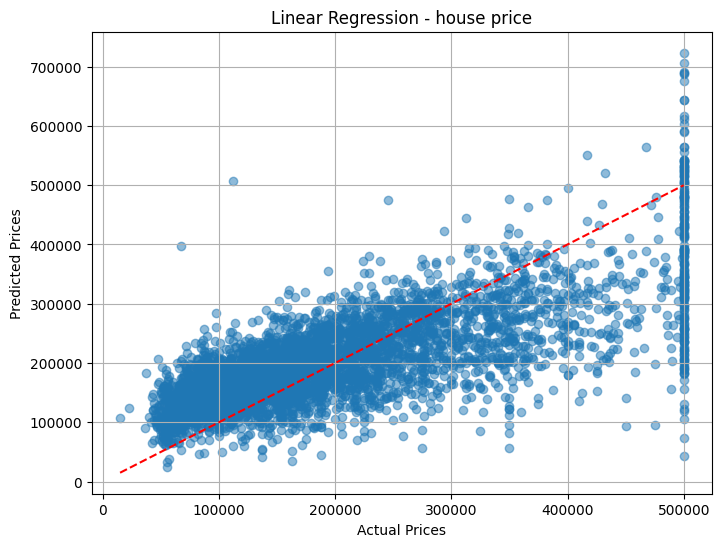

In [ ]:
df = df.dropna()
X = df[['median_income', 'population', 'total_rooms', 'housing_median_age']].values
y = df['median_house_value'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression - house price")
plt.grid(True)
plt.show()

assesing the performace of the regression model

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    mean_pinball_loss,
    d2_pinball_score,
    d2_absolute_error_score
)

metrics = {
    'Mean Squared Error (MSE)': mean_squared_error(y_test, y_pred),
    'Root Mean Squared Error (RMSE)': np.sqrt(mean_squared_error(y_test, y_pred)),
    'Mean Absolute Error (MAE)': mean_absolute_error(y_test, y_pred),
    'R-squared (R²)': r2_score(y_test, y_pred),
    'Explained Variance Score': explained_variance_score(y_test, y_pred),
    'Mean Pinball Loss (α=0.5)': mean_pinball_loss(y_test, y_pred, alpha=0.5),
    'D2 Pinball Score': d2_pinball_score(y_test, y_pred, alpha=0.5),
    'D2 Absolute Error Score': d2_absolute_error_score(y_test, y_pred)}
for name, value in metrics.items():
    print(f"{name}: {value:.4f}" if isinstance(value, (int, float)) else f"{name}: {value}")

print("\nInterpretation Guide:")
print("- MSE/RMSE/MAE: Lower is better (scale-dependent)")
print("- R²: 0-1, higher is better (1 = perfect fit)")
print("- Explained Variance: 0-1, less sensitive to outliers than R²)")
print("- Pinball Loss (α=0.5): Quantile loss for median prediction)")
print("- D2 Scores: Similar to R² but for quantile/absolute errors (1 = perfect)")


Mean Squared Error (MSE): 6602599478.6543
Root Mean Squared Error (RMSE): 81256.3812
Mean Absolute Error (MAE): 60866.5610
R-squared (R²): 0.5172
Explained Variance Score: 0.5172
Mean Pinball Loss (α=0.5): 30433.2805
D2 Pinball Score: 0.3237
D2 Absolute Error Score: 0.3237

Interpretation Guide:
- MSE/RMSE/MAE: Lower is better (scale-dependent)
- R²: 0-1, higher is better (1 = perfect fit)
- Explained Variance: 0-1, less sensitive to outliers than R²)
- Pinball Loss (α=0.5): Quantile loss for median prediction)
- D2 Scores: Similar to R² but for quantile/absolute errors (1 = perfect)


**question 2** Adjust the hyper parameters of the linear regression model and interprete the impact
of them on the final result.

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

# Create preprocessing and modeling pipeline
pipe = make_pipeline(
    RobustScaler(),  # Better for housing data which often has outliers
    LinearRegression()
)

# Parameter grid for tuning
param_grid = {
    'linearregression__fit_intercept': [True, False],
}

# For regularized models (uncomment if needed)
# param_grid.update({
#     'linearregression': [Ridge(), Lasso()],
#     'linearregression__alpha': [0.001, 0.01, 0.1, 1, 10]
# })

# Perform grid search
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

# Best model evaluation
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# Compare metrics
print(f"\nBest Parameters: {grid.best_params_}")
print(f"Original R²: {metrics['R-squared (R²)']:.4f}")
print(f"Tuned R²: {r2_score(y_test, y_pred_tuned):.4f}")


Best Parameters: {'linearregression__fit_intercept': True}
Original R²: 0.5172
Tuned R²: 0.5172


In [ ]:
from sklearn.linear_model import Ridge, Lasso

alphas = [0.01, 0.1, 1.0, 10.0]

for alpha in alphas:
    print(f"\n🔹 Ridge Regression (alpha = {alpha})")
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    ridge_pred = ridge_model.predict(X_test)

    print(f"R²: {r2_score(y_test, ridge_pred):.4f}")
    print(f"MSE: {mean_squared_error(y_test, ridge_pred):.2f}")
    print(f"MAE: {mean_absolute_error(y_test, ridge_pred):.2f}")

print("\n" + "="*50)

for alpha in alphas:
    print(f"\n🔹 Lasso Regression (alpha = {alpha})")
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_train, y_train)
    lasso_pred = lasso_model.predict(X_test)

    print(f"R²: {r2_score(y_test, lasso_pred):.4f}")
    print(f"MSE: {mean_squared_error(y_test, lasso_pred):.2f}")
    print(f"MAE: {mean_absolute_error(y_test, lasso_pred):.2f}")



🔹 Ridge Regression (alpha = 0.01)
R²: 0.5172
MSE: 6602599488.48
MAE: 60866.56

🔹 Ridge Regression (alpha = 0.1)
R²: 0.5172
MSE: 6602599576.91
MAE: 60866.57

🔹 Ridge Regression (alpha = 1.0)
R²: 0.5172
MSE: 6602600463.01
MAE: 60866.66

🔹 Ridge Regression (alpha = 10.0)
R²: 0.5172
MSE: 6602609506.36
MAE: 60867.52


🔹 Lasso Regression (alpha = 0.01)
R²: 0.5172
MSE: 6602599483.89
MAE: 60866.56

🔹 Lasso Regression (alpha = 0.1)
R²: 0.5172
MSE: 6602599531.03
MAE: 60866.56

🔹 Lasso Regression (alpha = 1.0)
R²: 0.5172
MSE: 6602600002.69
MAE: 60866.60

🔹 Lasso Regression (alpha = 10.0)
R²: 0.5172
MSE: 6602604749.05
MAE: 60866.94


**question 3** Use the sample KNN code presented in the course (Week 2) and develop a KNN regression model for the house price

📊 KNN Regression Results:
Mean Squared Error (MSE): 11700336984.20
Root Mean Squared Error (RMSE): 108168.10
Mean Absolute Error (MAE): 83596.18
R-squared (R²): 0.1444


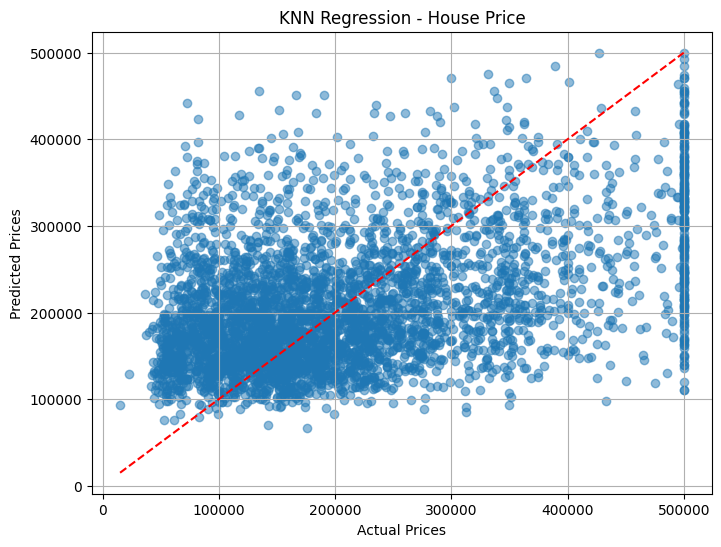

In [ ]:


X = df[['median_income', 'population', 'total_rooms', 'housing_median_age']].values
y = df['median_house_value'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Create and train KNN regressor
knn_model = KNeighborsRegressor(n_neighbors=5)  # You can change n_neighbors
knn_model.fit(X_train, y_train)

#  Predict on test data
y_pred = knn_model.predict(X_test)

#  Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 KNN Regression Results:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.4f}")

#  Visualize results
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("KNN Regression - House Price")
plt.grid(True)
plt.show()


question 4

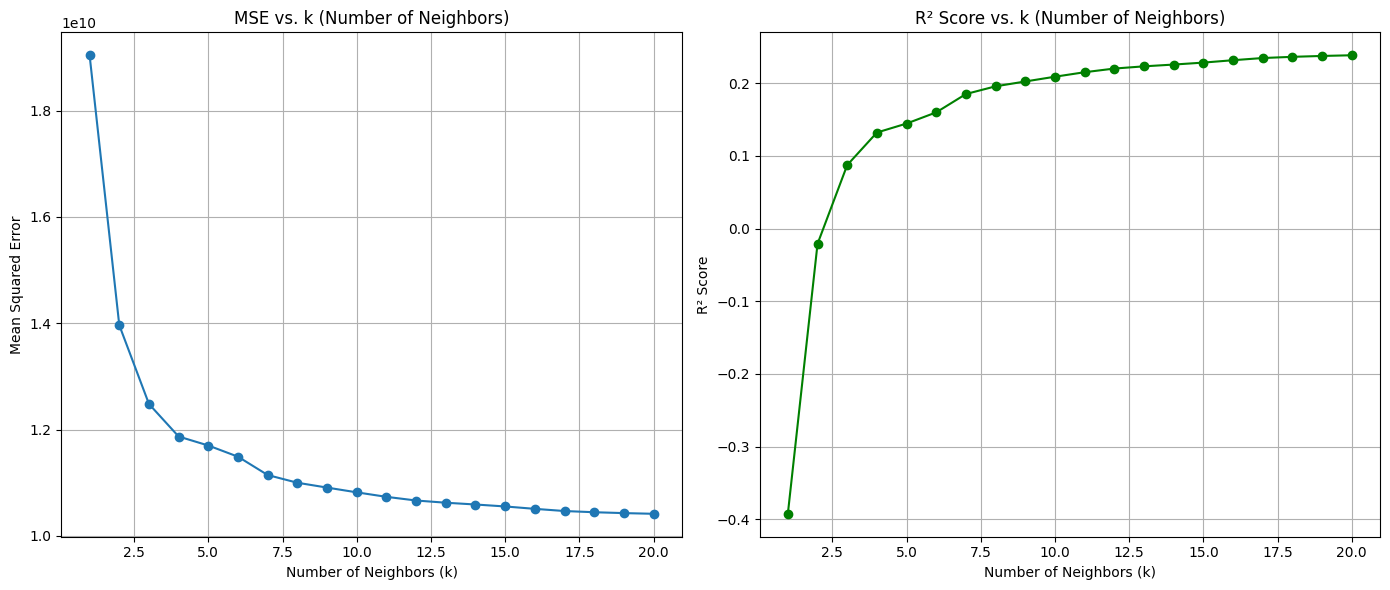

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Load the dataset
file_path = '/content/housing.csv'  # Update this if needed
df = pd.read_csv(file_path)

# 2. Drop missing values
df = df.dropna()

# 3. Define features and target
X = df[['median_income', 'population', 'total_rooms', 'housing_median_age']].values
y = df['median_house_value'].values

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Simulate for different k values
k_values = list(range(1, 21))
mse_scores = []
r2_scores = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))

# 6. Plot MSE and R² vs. k
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, mse_scores, marker='o')
plt.title("MSE vs. k (Number of Neighbors)")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, r2_scores, marker='o', color='green')
plt.title("R² Score vs. k (Number of Neighbors)")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("R² Score")
plt.grid(True)

plt.tight_layout()
plt.show()


question 5

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
file_path = '/content/housing.csv'  # Update path if needed
df = pd.read_csv(file_path)

# 2. Drop missing values
df.dropna(inplace=True)

# 3. Select features and target variable
X = df[['median_income', 'population', 'total_rooms', 'housing_median_age']]
y = df['median_house_value']

# 4. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Standardize the features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train the Linear Regression model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# 7. Train the KNN Regression model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# 8. Define the input for prediction
new_data = pd.DataFrame({
    'median_income': [15.8],     # in $100,000
    'population': [232],
    'total_rooms': [6],
    'housing_median_age': [2]
})

# 9. Predict using Linear Regression
pred_lin = lin_model.predict(new_data)[0]

# 10. Predict using KNN (scaled input)
new_data_scaled = scaler.transform(new_data)
pred_knn = knn_model.predict(new_data_scaled)[0]

# 11. Display predictions
print(f"🔹 Predicted House Price using Linear Regression: ${pred_lin:,.2f}")
print(f"🔹 Predicted House Price using KNN Regression (k=5): ${pred_knn:,.2f}")


🔹 Predicted House Price using Linear Regression: $636,293.16
🔹 Predicted House Price using KNN Regression (k=5): $470,000.80
